In [43]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Download latest version
path = kagglehub.dataset_download("govindaramsriram/car-insurance-premium-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-insurance-premium-dataset' dataset.
Path to dataset files: /kaggle/input/car-insurance-premium-dataset


In [24]:
df = pd.read_csv("/kaggle/input/car-insurance-premium-dataset/car_insurance_premium_dataset.csv")

In [38]:
display(df)

,Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age,Insurance Premium ($)
0,56,32,4,17,2002,23,488.35
1,46,19,0,21,2025,0,486.15
2,32,11,4,15,2020,5,497.55
3,60,0,4,19,1991,34,498.35
4,25,7,0,13,2005,20,495.55
...,...,...,...,...,...,...,...
995,23,5,3,22,2020,5,500.00
996,43,8,3,17,2023,2,494.55
997,21,3,5,19,1998,27,506.05
998,36,18,1,23,2011,14,491.45


In [26]:
df.shape

(1000, 7)

In [29]:
X_columns = df.columns[:-1]

In [32]:
X_train, X_test = df[X_columns].iloc[:800], df[X_columns].iloc[800:]
y_train, y_test = df["Insurance Premium ($)"].iloc[:800], df["Insurance Premium ($)"].iloc[800:]

In [33]:
print(X_train.shape, X_test.shape)

(800, 6) (200, 6)


In [39]:
display(y_train)

,Insurance Premium ($)
0,488.35
1,486.15
2,497.55
3,498.35
4,495.55
...,...
795,499.90
796,490.30
797,488.30
798,488.25


In [35]:
for col in X_columns:
  X_train[col] = (X_train[col] - X_train[col].sum()/len(X_train))/X_train[col].std()
  X_test[col] = (X_test[col] - X_test[col].sum()/len(X_test))/X_test[col].std()

In [37]:
display(X_train)
display(X_test)

,Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age
0,1.043005,1.623474,0.827919,-0.214558,-0.523901,0.523901
1,0.313503,0.388080,-1.522871,0.690034,1.674954,-1.674954
2,-0.707799,-0.372162,0.827919,-0.666854,1.196942,-1.196942
3,1.334806,-1.417496,0.827919,0.237738,-1.575528,1.575528
4,-1.218450,-0.752284,-1.522871,-1.119149,-0.237094,0.237094
...,...,...,...,...,...,...
795,0.386454,-0.657253,1.415616,1.368478,-1.193118,1.193118
796,-0.561899,0.102989,-1.522871,-0.893002,0.527725,-0.527725
797,1.699557,1.433413,1.415616,1.368478,0.145316,-0.145316
798,1.626607,1.528444,1.415616,1.594625,0.145316,-0.145316


,Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age
800,-0.646703,-0.294383,0.310785,0.715275,1.377905,-1.377905
801,0.922792,-0.670591,0.310785,-1.112904,0.876302,-0.876302
802,-0.218659,-0.670591,-1.465127,0.029708,-1.130113,1.130113
803,-0.718044,-0.106279,0.310785,-1.112904,-1.832358,1.832358
804,-1.574132,-1.234902,-1.465127,1.400842,0.274377,-0.274377
...,...,...,...,...,...,...
995,-1.288770,-0.858694,0.310785,0.943797,1.177264,-1.177264
996,0.138044,-0.576539,0.310785,-0.198814,1.478226,-1.478226
997,-1.431451,-1.046798,1.494726,0.258230,-1.029792,1.029792
998,-0.361341,0.363981,-0.873157,1.172320,0.274377,-0.274377


In [42]:
w = np.zeros(6, dtype=np.float64)
b = 0.0
lr = 0.001
alpha = 10.0
N = len(X_train)

for i in range(8000):
  y_dot = X_train@w + b
  e = y_dot - y_train
  db = e.sum()/N
  dw = (1 / N) * (X_train.T @ e) + (alpha / N) * w
  b = b - lr*db
  w = w - lr*dw
  if i%1000==0:
    print("MAE: ",f"{np.sum(np.abs(y_dot-y_train))/N:.2f}", end = "  ")
    print("RMSE: ", f"{np.sqrt(np.sum(((y_dot-y_train)**2)/N)):.2f}", end = "  ")

    y_mean = np.mean(y_train)
    ss_res = np.sum((y_train - y_dot) ** 2)
    ss_tot = np.sum((y_train - y_mean) ** 2)
    r2_score = 1 - (ss_res / ss_tot)
    print("R2 Score: ", f"{r2_score:.2f}")

MAE:  493.72  RMSE:  493.76  R2 Score:  -7052.13
MAE:  181.54  RMSE:  181.55  R2 Score:  -952.51
MAE:  66.75  RMSE:  66.75  R2 Score:  -127.91
MAE:  24.54  RMSE:  24.54  R2 Score:  -16.43
MAE:  9.02  RMSE:  9.03  R2 Score:  -1.36
MAE:  3.32  RMSE:  3.32  R2 Score:  0.68
MAE:  1.22  RMSE:  1.22  R2 Score:  0.96
MAE:  0.45  RMSE:  0.45  R2 Score:  0.99


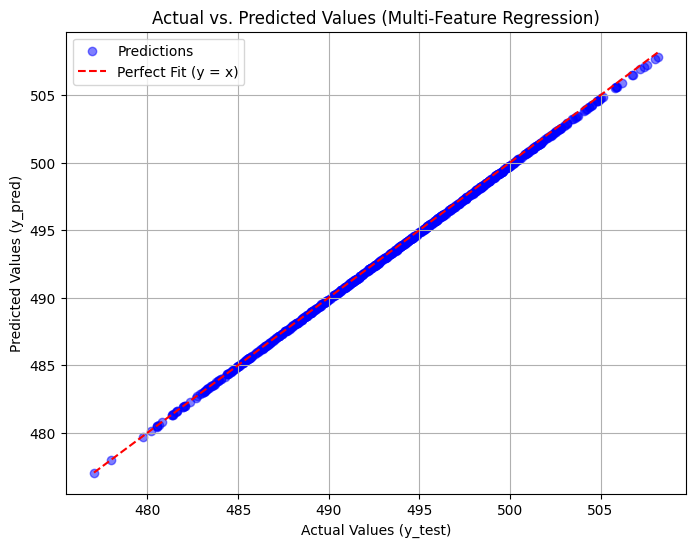

In [44]:
y_pred = X_train @ w + b

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred, color='blue', alpha=0.5, label='Predictions')

min_val = min(y_train.min(), y_pred.min())
max_val = max(y_train.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit (y = x)')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values (Multi-Feature Regression)')
plt.legend()
plt.grid(True)
plt.show()

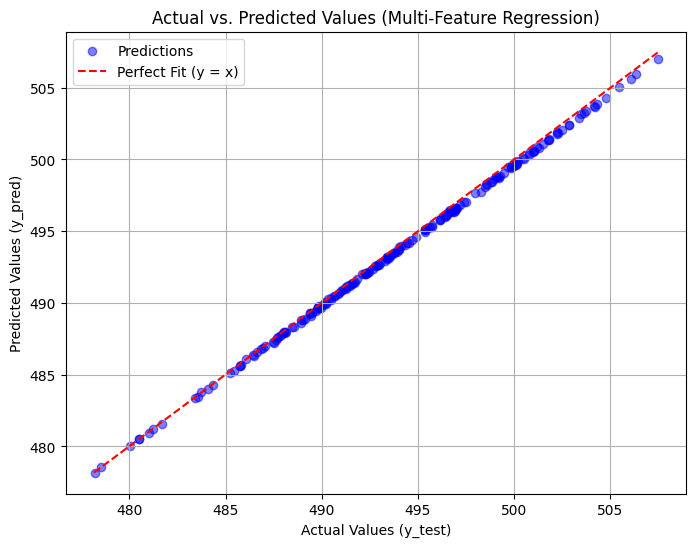

In [45]:
y_pred = X_test @ w + b

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit (y = x)')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values (Multi-Feature Regression)')
plt.legend()
plt.grid(True)
plt.show()